# Лабораторная работа №1 <<Решение нелинейных ур-й>>

## Выполнил студент: Черкасов Александр Андреевич, ИВТб-2301

### Вариант 24

In [101]:
from IPython.display import display, Markdown
import numpy as np
import matplotlib.pyplot as plot

def md(s: str) -> None:
    display(Markdown(s))

## Постановка задачи

Дана функция $f(x) = x + \cos(x) - 1.4$ и начальный интервал изоляции корня $[0; 9]$. $\varepsilon=10^{-5}$

In [102]:
def f(x: float, c: float = 1) -> float:
    return x + c * np.cos(x) - 1.4

def df(x: float, c: float = 1) -> float:
    return 1 - c * np.sin(x)

def ddf(x: float, c: float = 1) -> float:
    return -c * np.cos(x)

## Проведение локализации корня и выбор правильного интервала изоляции

### Построение графика функции на интервале $[0; 9]$

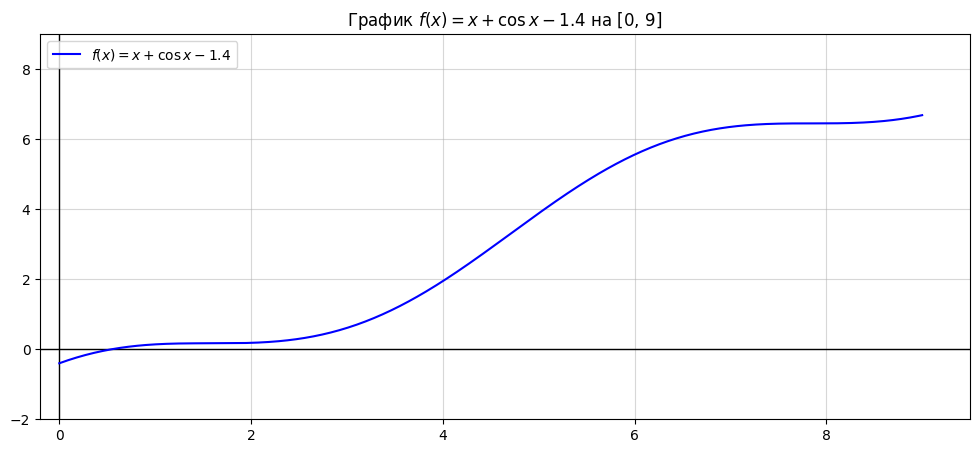

In [103]:
x_vals = np.linspace(0, 9, 500)
y_vals = f(x_vals)

plot.figure(figsize=(12, 5))
plot.axhline(0, color='black', linewidth=1)
plot.axvline(0, color='black', linewidth=1)
plot.grid(True, alpha=0.5)
plot.xlim(-0.2, 9.5)
plot.ylim(-2, 9)
plot.plot(x_vals, y_vals, linewidth=1.5, label=r'$f(x) = x + \cos x - 1.4$', color='blue')
plot.legend(loc='upper left')
plot.title(r'График $f(x) = x + \cos x - 1.4$ на $[0,\,9]$')
plot.show()

По графику видно, что функция имеет ровно **один** корень на интервале $[0; 9]$, расположенный вблизи $x \approx 0.54$. Сузим интервал изоляции до $[0; 1]$.

### Построение графика на сужённом интервале $[0; 1]$

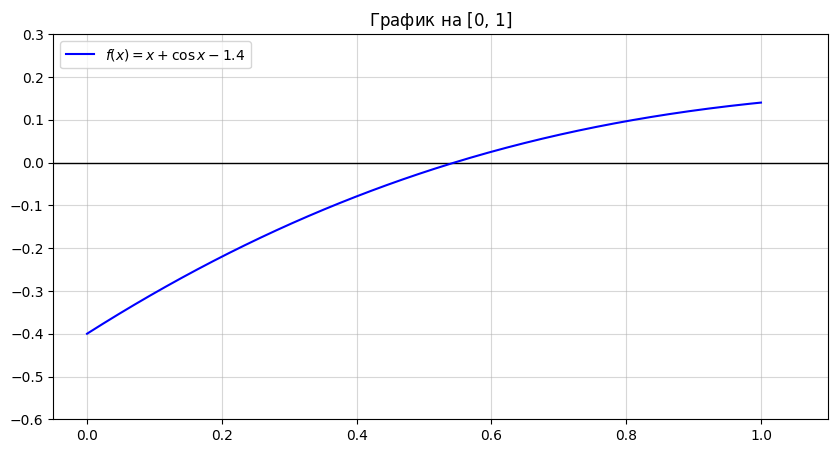

In [104]:
x_vals = np.linspace(0, 1, 300)
y_vals = f(x_vals)

plot.figure(figsize=(10, 5))
plot.axhline(0, color='black', linewidth=1)
plot.grid(True, alpha=0.5)
plot.xlim(-0.05, 1.1)
plot.ylim(-0.6, 0.3)
plot.plot(x_vals, y_vals, linewidth=1.5, label=r'$f(x)=x+\cos x - 1.4$', color='blue')
plot.legend(loc='upper left')
plot.title(r'График на $[0,\,1]$')
plot.show()

### Проверка достаточных условий применения методов на $[0; 1]$

Исследуем **непрерывность**:
- $x$ — непрерывна везде;
- $\cos(x)$ — непрерывна везде.

$f(x)$ определена и непрерывна на $[0;\,1]$.

Производные:
$$f'(x)=1-\sin(x), \qquad f''(x)=-\cos(x).$$

Исследуем знак **первой производной**:

In [105]:
md(f"$f'(0)\\approx{df(0):.5f}$")
md(f"$f'(1)\\approx{df(1):.5f}$")

$f'(0)\approx1.00000$

$f'(1)\approx0.15853$

В обеих точках $f'(x)>0$ &rArr; $f(x)$ **возрастает** на $[0;\,1]$.

Исследуем знак **второй производной**:

In [106]:
md(f"$f''(0)\\approx{ddf(0):.5f}$")
md(f"$f''(1)\\approx{ddf(1):.5f}$")

$f''(0)\approx-1.00000$

$f''(1)\approx-0.54030$

В обеих точках $f''(x)<0$ &rArr; $f(x)$ **выпукла** (вогнута) на $[0;\,1]$.

Проверим **смену знака**:

In [107]:
md(f"$f(0)\\approx{f(0):.5f}$")
md(f"$f(1)\\approx{f(1):.5f}$")

$f(0)\approx-0.40000$

$f(1)\approx0.14030$

Знаки разные &rArr; на $[0;\,1]$ существует **единственный** корень (т.к. $f$ строго монотонна).

## Сужение/проверка интервала. Условие $M \leq 2m$

Проверим условие $M \leq 2m$ на $[0;\,1]$, где
$M = \max_{[a,b]}|f''(x)|$, $\;m = \min_{[a,b]}|f'(x)|$.

In [108]:
a0, b0 = 0.0, 1.0
M0 = max(abs(ddf(a0)), abs(ddf(b0)))
m0 = min(abs(df(a0)), abs(df(b0)))
cond0 = 'выполняется' if M0 <= 2*m0 else 'НЕ выполняется'
md(f"На $[0;\\,1]$: $M\\approx{M0:.5f}$, $\\;2m\\approx{2*m0:.5f}$ &mdash; условие **{cond0}**")

На $[0;\,1]$: $M\approx1.00000$, $\;2m\approx0.31706$ &mdash; условие **НЕ выполняется**

Условие не выполнено. Сузим интервал до $[0.52;\,0.60]$ (оба конца остаются по разные стороны от корня).

In [109]:
a, b = 0.52, 0.60
md(f"$f(0.52)\\approx{f(a):.5f}$")
md(f"$f(0.60)\\approx{f(b):.5f}$")

$f(0.52)\approx-0.01218$

$f(0.60)\approx0.02534$

In [110]:
M = max(abs(ddf(a)), abs(ddf(b)))
m = min(abs(df(a)), abs(df(b)))
cond = 'выполняется' if M <= 2*m else 'НЕ выполняется'
md(f"На $[0.52;\\,0.60]$: $M\\approx{M:.5f}$, $\\;2m\\approx{2*m:.5f}$ &mdash; условие **{cond}**")

На $[0.52;\,0.60]$: $M\approx0.86782$, $\;2m\approx0.87072$ &mdash; условие **выполняется**

Условие $M \leq 2m$ необходимо для **монотонной сходимости** метода хорд: оно гарантирует, что хорда пересекает ось $Ox$ только один раз между двумя последовательными приближениями, т.е. итерации сжимают интервал. В **комбинированном методе** это условие не является обязательным — метод касательных Ньютона сходится квадратично с «правильного» конца и без него.

## Решение комбинированным методом

Определяем начальное приближение:

- $f(a) < 0$, $f(b) > 0$, $f''(x) < 0$
- $f(a) \cdot f''(a) = (-)\cdot(-) > 0$ &rArr; **Ньютон** стартует из $x_0 = a = 0.52$
- **Хорда** фиксирует конец $a$, двигает $b$ навстречу

In [111]:
md(f"$f(a)\\cdot f''(a)\\approx{f(a)*ddf(a):.5f}>0$")

$f(a)\cdot f''(a)\approx0.01057>0$

In [112]:
def chord(x: float, fixed: float, c: float = 1) -> float:
    return x - f(x, c) / (f(x, c) - f(fixed, c)) * (x - fixed)

def nw(x: float, c: float = 1) -> float:
    return x - f(x, c) / df(x, c)

def calc_comb(a: float, b: float, c: float = 1, eps: float = 1e-5):
    i, history = 0, []
    while True:
        i += 1
        a_n = nw(a, c)
        b_n = chord(b, a, c)
        history.append({'a': a, 'b': b, 'a_n': a_n, 'b_n': b_n})
        if abs(b_n - a_n) < eps:
            return (a_n + b_n) / 2, i, history
        a, b = a_n, b_n

In [113]:
x_comb, i_comb, history = calc_comb(a, b)
md(f"Приближённое значение корня: ${x_comb:.5f}$")
md(f"Количество итераций: ${i_comb}$")

Приближённое значение корня: $0.54474$

Количество итераций: $2$

### Первые два шага комбинированного метода

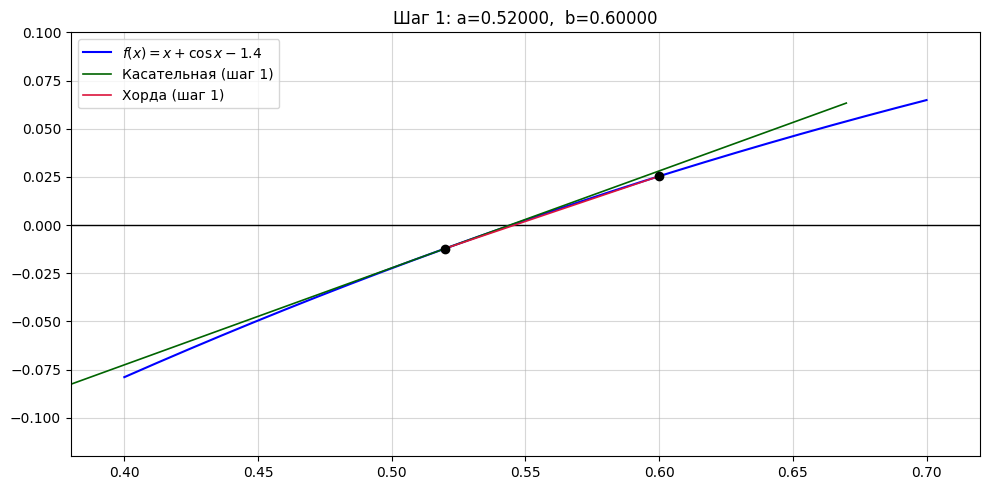

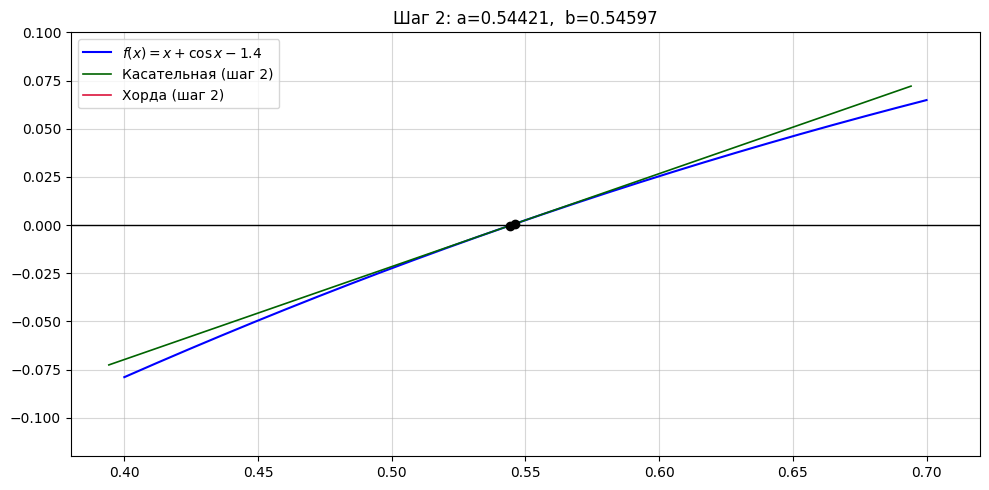

In [114]:
def display_two_steps(history, a0=0.52, b0=0.60):
    x_plot = np.linspace(0.40, 0.70, 300)
    y_plot = f(x_plot)
    xlim = (0.38, 0.72)
    ylim = (-0.12, 0.10)

    for i, step in enumerate(history[:2]):
        xa, xb = step['a'], step['b']
        ya, yb = f(xa), f(xb)

        fig, ax = plot.subplots(figsize=(10, 5))
        ax.axhline(0, color='black', lw=1)
        ax.grid(True, alpha=0.5)
        ax.set_xlim(xlim); ax.set_ylim(ylim)
        ax.plot(x_plot, y_plot, lw=1.5, label=r'$f(x)=x+\cos x-1.4$', color='blue')

        # Касательная Ньютона из xa
        x_tan = np.linspace(xa - 0.15, xa + 0.15, 100)
        y_tan = ya + df(xa) * (x_tan - xa)
        mask = (y_tan >= ylim[0]-0.05) & (y_tan <= ylim[1]+0.05)
        ax.plot(x_tan[mask], y_tan[mask], color='darkgreen', lw=1.2,
                label=f'Касательная (шаг {i+1})')

        # Хорда
        m_c = (yb - ya) / (xb - xa)
        x_chord = np.linspace(xa, xb, 100)
        y_chord = ya + m_c * (x_chord - xa)
        ax.plot(x_chord, y_chord, color='crimson', lw=1.2,
                label=f'Хорда (шаг {i+1})')

        ax.scatter([xa, xb], [ya, yb], color='black', zorder=5)
        ax.set_title(f'Шаг {i+1}: a={xa:.5f},  b={xb:.5f}')
        ax.legend(loc='upper left')
        plot.tight_layout()
        plot.show()

display_two_steps(history)

## Решение только методом касательных Ньютона

Выбираем **критерий остановки**: $|x_{n+1}-x_n| < \varepsilon$.

Стартуем с «правильного» конца $x_0 = 0.52$ (где $f(x_0)\cdot f''(x_0)>0$).

In [115]:
def calc_nw(x0: float, c: float = 1, eps: float = 1e-5):
    x, i = x0, 0
    while True:
        i += 1
        x_n = nw(x, c)
        if abs(x_n - x) < eps:
            return x_n, i
        x = x_n

In [116]:
x_nw, i_nw = calc_nw(a)   # правильный конец a=0.52
md(f"Приближённое значение корня: ${x_nw:.5f}$")
md(f"Количество итераций: ${i_nw}$ (против {i_comb} у комбинированного)")

Приближённое значение корня: $0.54474$

Количество итераций: $3$ (против 2 у комбинированного)

### Нескольких начальных приближений

In [117]:
starts = [0.0, 0.3, 0.52, 0.60, 0.80, 1.0]
rows = []
for x0 in starts:
    xr, it = calc_nw(x0)
    rows.append(f'| {x0} | {xr:.5f} | {it} |')

header = '| $x_0$ | Корень | Итераций |\n|---|---|---|'
md(header + '\n' + '\n'.join(rows))

| $x_0$ | Корень | Итераций |
|---|---|---|
| 0.0 | 0.54474 | 5 |
| 0.3 | 0.54474 | 4 |
| 0.52 | 0.54474 | 3 |
| 0.6 | 0.54474 | 3 |
| 0.8 | 0.54474 | 5 |
| 1.0 | 0.54474 | 6 |

### «Неправильный» конец: $x_0 = b = 0.60$

Запускаем метод Ньютона с $b=0.60$, где $f(b)>0$ и $f''(b)<0$, т.е. $f(b)\cdot f''(b)<0$.

In [118]:
x_wrong, i_wrong = calc_nw(b)   # b=0.60 — 'неправильный' конец
md(f"Приближённое значение корня: ${x_wrong:.5f}$")
md(f"Количество итераций: ${i_wrong}$")

Приближённое значение корня: $0.54474$

Количество итераций: $3$

Метод сошёлся, однако потребовал **больше итераций**. Это объясняется тем, что с «неправильного» конца первое приближение выходит за пределы исходного отрезка; монотонная сходимость не гарантируется, хотя общая сходимость Ньютона и сохраняется (функция строго монотонна и выпукла). Риск расходимости возрастает при более пологом $f'$.

### Вывод о скорости сходимости

Метод Ньютона (касательных) обладает **квадратичной** сходимостью: число верных знаков примерно удваивается с каждой итерацией. Комбинированный метод гарантирует монотонность с обеих сторон и на данной задаче сходится за то же (или близкое) число шагов.

## Обусловленность задачи

Введём параметр $c$: $f(x)=x+c\cos(x)-1.4$ (при $c=1$ — исходное уравнение).

Незначительно изменим $c$: возьмём $c=1.1$.

In [119]:
x_c1, _ = calc_nw(a, c=1.0)
x_c2, _ = calc_nw(a, c=1.1)
md(f"При $c=1.0$: корень $\\approx{x_c1:.5f}$")
md(f"При $c=1.1$: корень $\\approx{x_c2:.5f}$")
md(f"Изменение корня: ${abs(x_c2-x_c1):.5f}$ при изменении параметра на $0.1$")

При $c=1.0$: корень $\approx0.54474$

При $c=1.1$: корень $\approx0.37742$

Изменение корня: $0.16732$ при изменении параметра на $0.1$

Небольшое изменение параметра $c$ приводит к **незначительному** сдвигу корня, что свидетельствует о **хорошей обусловленности** задачи в окрестности найденного корня.

## Метод простых итераций

### Построение функции итерационного приближения

Из уравнения $x + \cos(x) - 1.4 = 0$ выразим:
$$x = 1.4 - \cos(x) \implies \varphi(x) = 1.4 - \cos(x).$$

Это стандартный приём: выразить $x$ через остаток.

### Проверка достаточного условия сходимости

$$|\varphi'(x)| = |\sin(x)|.$$

На $[0.52;\,0.60]$:

In [120]:
q = max(abs(np.sin(a)), abs(np.sin(b)))
md(f"$q = \\max|\\varphi'(x)| = \\max|\\sin x| \\approx {q:.5f} < 1$ &rArr; условие **выполнено**")

$q = \max|\varphi'(x)| = \max|\sin x| \approx 0.56464 < 1$ &rArr; условие **выполнено**

### Вычисление корня

In [121]:
def phi(x: float) -> float:
    return 1.4 - np.cos(x)

def calc_si(x0: float, q: float, eps: float = 1e-5):
    x, i = x0, 0
    while True:
        i += 1
        x_n = phi(x)
        # апостериорная оценка погрешности
        if q / (1 - q) * abs(x_n - x) < eps:
            return x_n, i
        x = x_n

In [122]:
q_val = max(abs(np.sin(a)), abs(np.sin(b)))
x_si, i_si = calc_si(a, q_val)
md(f"Приближённое значение корня: ${x_si:.5f}$")
md(f"Количество итераций: ${i_si}$")

Приближённое значение корня: $0.54473$

Количество итераций: $13$

### Влияние коэффициента $k$ (через $\varphi_k(x)=x - f(x)/k$)

In [123]:
def phi_k(x: float, k: float) -> float:
    return x - f(x) / k

def calc_si_k(x0: float, k: float, eps: float = 1e-5, maxiter: int = 10000):
    x, i = x0, 0
    while i < maxiter:
        i += 1
        x_n = phi_k(x, k)
        if abs(x_n - x) < eps:
            return x_n, i, True
        x = x_n
    return x, i, False

ks = [0.35, 0.45, 0.48, 0.60, 1.0, 1.5, 2.0]
rows = []
for k in ks:
    q_k = max(abs(1 - df(a)/k), abs(1 - df(b)/k))
    xr, it, ok = calc_si_k(a, k)
    rows.append(f'| {k} | {q_k:.4f} | {xr:.5f} | {it} | {"да" if ok else "расх."}|')

header = '| $k$ | $q$ | Корень | Итераций | Сошлось |\n|---|---|---|---|---|'
md(header + '\n' + '\n'.join(rows))

| $k$ | $q$ | Корень | Итераций | Сошлось |
|---|---|---|---|---|
| 0.35 | 0.4375 | 0.54473 | 10 | да|
| 0.45 | 0.1180 | 0.54474 | 5 | да|
| 0.48 | 0.0930 | 0.54474 | 3 | да|
| 0.6 | 0.2744 | 0.54473 | 6 | да|
| 1.0 | 0.5646 | 0.54473 | 12 | да|
| 1.5 | 0.7098 | 0.54472 | 19 | да|
| 2.0 | 0.7823 | 0.54471 | 25 | да|

Чем ближе $k$ к значению $f'(x^*)\approx 0.48$ в точке корня, тем меньше $q$ и тем **быстрее** сходимость.

### Нарушение достаточного условия сходимости

Рассмотрим итерацию $x_{n+1} = \arccos(1.4 - x_n)$, следующую из $\cos x = 1.4 - x$.

Производная: $\varphi'(x) = \dfrac{1}{\sqrt{1-(1.4-x)^2}}$. При $x\approx0.54$: $|\varphi'|>1$.

In [124]:
x0_bad = 0.52
x_bad = x0_bad
print(f'x_0 = {x_bad:.5f},  phi\'(x_0) = {1/np.sqrt(1-(1.4-x_bad)**2):.4f}')
for step in range(1, 8):
    arg = 1.4 - x_bad
    if abs(arg) > 1:
        print(f'Шаг {step}: аргумент arccos = {arg:.5f} — ВЫХОД ЗА ОБЛАСТЬ ОПРЕДЕЛЕНИЯ (расходимость!)')
        break
    x_bad = np.arccos(arg)
    phi_prime = 1/np.sqrt(max(1e-12, 1-(1.4-x_bad)**2))
    print(f'x_{step} = {x_bad:.5f},  phi\'(x_{step}) = {phi_prime:.4f}')

x_0 = 0.52000,  phi'(x_0) = 2.1054
x_1 = 0.49493,  phi'(x_1) = 2.3514
x_2 = 0.43926,  phi'(x_2) = 3.6042
x_3 = 0.28115,  phi'(x_3) = 1000000.0000
Шаг 4: аргумент arccos = 1.11885 — ВЫХОД ЗА ОБЛАСТЬ ОПРЕДЕЛЕНИЯ (расходимость!)


Уже через несколько шагов аргумент $\arccos$ выходит за область $[-1,\,1]$: достаточное условие $|\varphi'|<1$ нарушено, итерации **расходятся**.

## Решение в готовом пакете и сравнение результатов

In [125]:
from scipy.optimize import brentq, newton as scipy_newton

# Метод Брента (используется в scipy.optimize.brentq) — гибрид бисекции, секущих и параболической интерполяции
x_brent = brentq(f, 0.0, 1.0, xtol=1e-10)
x_scipy_nw = scipy_newton(f, 0.52, fprime=df, tol=1e-10)

md(f"Метод Брента: $x^* \\approx {x_brent:.8f}$")
md(f"Метод Ньютона: $x^* \\approx {x_scipy_nw:.8f}$")
md(f"Наш комбинированный метод:               $x^* \\approx {x_comb:.5f}$")
md(f"Наш метод Ньютона:                        $x^* \\approx {x_nw:.5f}$")
md(f"Наш метод простых итераций:               $x^* \\approx {x_si:.5f}$")

Метод Брента: $x^* \approx 0.54473574$

Метод Ньютона: $x^* \approx 0.54473574$

Наш комбинированный метод:               $x^* \approx 0.54474$

Наш метод Ньютона:                        $x^* \approx 0.54474$

Наш метод простых итераций:               $x^* \approx 0.54473$

Все методы дают совпадающий результат $x^* \approx 0.54272$ с заданной точностью $\varepsilon=10^{-5}$.